In [27]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np

In [28]:
# Open model from folder
with open("model.pkl", 'rb') as file_1:
  model = pickle.load(file_1)

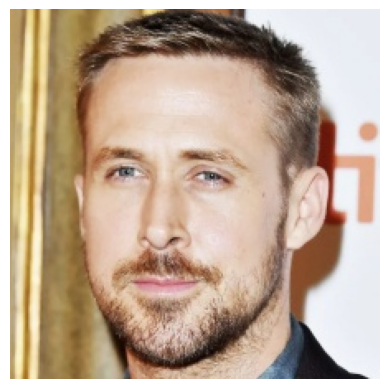

In [29]:
# Pick inference image and illustrate (Can be replaced with another image)
test_image = mpimg.imread('TE__ovale__ovale t1.jpg')
plt.imshow(test_image)
plt.axis("off")
plt.show()

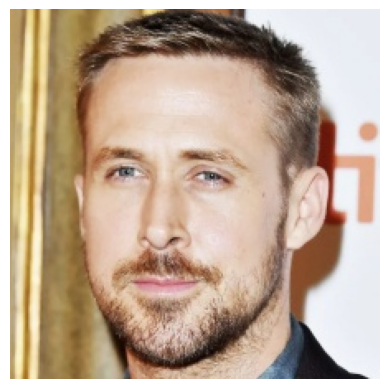

In [30]:
target_size = (224, 224)

def resize(image):
    image = cv2.resize(image, target_size)
    return image
test_image = resize(test_image)
plt.imshow(test_image)
plt.axis("off")
plt.show()

test_image = test_image / 255.

In [31]:
# Predict an image

y_pred = model.predict(np.expand_dims(test_image, 0))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


array([[8.8441974e-01, 1.1461645e-01, 9.3755062e-04, 2.6178473e-05]],
      dtype=float32)

In [32]:
# Probability for each class
class_names = class_names = ["ovale", "rectangular", "round", "square"]
y_pred_df = pd.DataFrame(y_pred, columns=class_names)
y_pred_df

,ovale,rectangular,round,square
0,0.88442,0.114616,0.000938,0.000026


In [33]:
# Get class prediction

y_pred_class = np.argmax(y_pred[0])
y_pred_class_name = class_names[np.argmax(y_pred[0])]

print('Prediction - Class       : ', y_pred_class)
print('Prediction - Class Name  : ', y_pred_class_name)

Prediction - Class       :  0
Prediction - Class Name  :  ovale


In [34]:
#Source : https://clippersbarbershop-tx.com/mens-haircuts-by-face-shape/

if y_pred_class_name == "square":
    print("Hairstyle:",y_pred_class_name)
    print("Recommended Hairstyle: Textured crop, quiff, high fade, undercut, side part, pompadour")

if y_pred_class_name == "ovale":
    print("Hairstyle:",y_pred_class_name)
    print("Recommended Hairstyle: Crew cut, textured crop, side part taper, undercut, pompadour")

if y_pred_class_name == "round":
    print("Hairstyle:",y_pred_class_name)
    print("Recommended Hairstyle: High fade with textured top, pompadour, quiff, side part, faux hawk")

if y_pred_class_name == "rectangular":
    print("Hairstyle:",y_pred_class_name)
    print("Recommended Hairstyle: Layered or medium-length styles, side part with texture, shoulder-length/shaggy styles")

Hairstyle: ovale
Recommended Hairstyle: Crew cut, textured crop, side part taper, undercut, pompadour
